## 1) Loading libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## 2) Loading, cleaning and preprocessing the dataset

In [3]:
df = pd.read_csv("movies.csv")

df = df[['name','genre','year','score','votes','budget','gross','runtime']]

numeric_cols = ['year','score','votes','budget','gross','runtime']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5435, 8)
                                             name      genre  year  score  \
0                                     The Shining      Drama  1980    8.4   
1                                 The Blue Lagoon  Adventure  1980    5.8   
2  Star Wars: Episode V - The Empire Strikes Back     Action  1980    8.7   
3                                       Airplane!     Comedy  1980    7.7   
4                                      Caddyshack     Comedy  1980    7.3   

       votes      budget        gross  runtime  
0   927000.0  19000000.0   46998772.0    146.0  
1    65000.0   4500000.0   58853106.0    104.0  
2  1200000.0  18000000.0  538375067.0    124.0  
3   221000.0   3500000.0   83453539.0     88.0  
4   108000.0   6000000.0   39846344.0     98.0  


## 3) Distribution of IMDb Scores

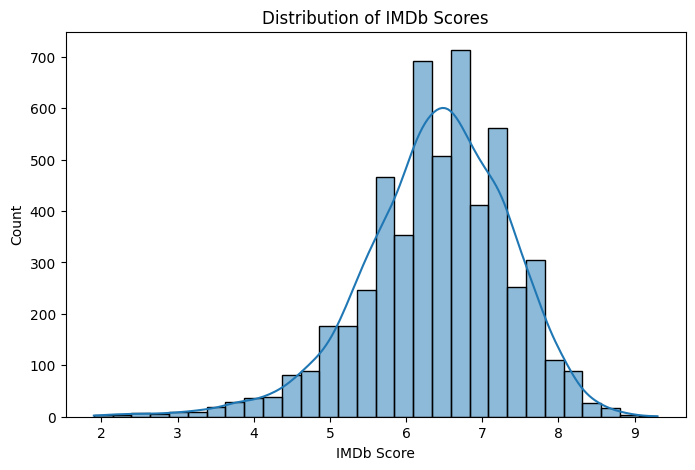

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(df['score'], bins=30, kde=True)

plt.title("Distribution of IMDb Scores")
plt.xlabel("IMDb Score")
plt.ylabel("Count")

plt.savefig("score_distribution.png")

plt.show()

## 4) Budget vs Popularity

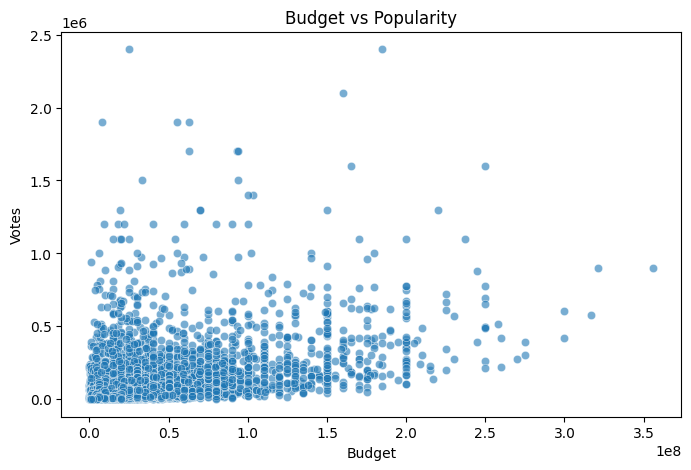

In [5]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='budget', y='votes', alpha=0.6)

plt.title("Budget vs Popularity")
plt.xlabel("Budget")
plt.ylabel("Votes")

plt.savefig("budget_vs_popularity.png")

plt.show()

## 5) Hypothesis Testing

In [6]:
median_budget = df['budget'].median()

high_budget = df[df['budget'] >= median_budget]['votes']
low_budget = df[df['budget'] < median_budget]['votes']

t_stat, p_value = ttest_ind(high_budget, low_budget, equal_var=False)

print("===== Hypothesis Test Result =====")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H0: High-budget and low-budget movies differ significantly in popularity.")
else:
    print("Fail to Reject H0: No significant difference found.")

===== Hypothesis Test Result =====
T-Statistic: 20.355620715572655
P-Value: 5.065341627756572e-88
Reject H0: High-budget and low-budget movies differ significantly in popularity.


## 6) Linear Regression Model

===== Linear Regression Result =====
MSE: 21134358032.677402
R2 Score: 0.36408144338848847


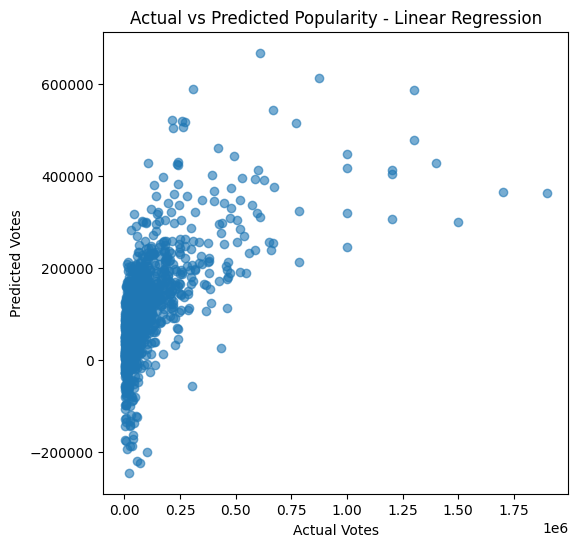

In [7]:
X = df[['budget','score','runtime']]
y = df['votes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("===== Linear Regression Result =====")
print("MSE:", mse_linear)
print("R2 Score:", r2_linear)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_linear, alpha=0.6)

plt.xlabel("Actual Votes")
plt.ylabel("Predicted Votes")

plt.title("Actual vs Predicted Popularity - Linear Regression")

plt.savefig("actual_vs_predicted_linear.png")

plt.show()

## 7) Random Forest Model

===== Random Forest Result =====
Random Forest R2 Score: 0.7131707793978185


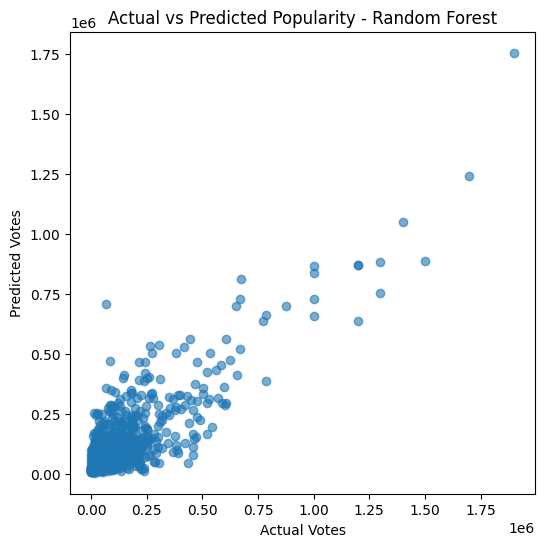

In [8]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)

print("===== Random Forest Result =====")
print("Random Forest R2 Score:", r2_rf)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel("Actual Votes")
plt.ylabel("Predicted Votes")

plt.title("Actual vs Predicted Popularity - Random Forest")

plt.savefig("actual_vs_predicted_rf.png")

plt.show()